# LC scenario water balance outputs 24.07.2026


In [2]:
# Install required packages

import pandas as pd
from pathlib import Path
# from urlpath import URL      
import os                      
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [5]:
# Load modelled overland flow to river, and actual ET outputs

MB_scen1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB/MB_wb_scen1_i.txt", sep="\\t")
MB_scen1["Time"] = pd.to_datetime(MB_scen1["Time"])
MB_scen1 = MB_scen1.set_index("Time")

MB_aff1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB/MB_wb_aff1_i.txt", sep="\\t")
MB_aff1["Time"] = pd.to_datetime(MB_aff1["Time"])
MB_aff1 = MB_aff1.set_index("Time")

MB_aff2 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB/MB_wb_aff2_i.txt", sep="\\t")
MB_aff2["Time"] = pd.to_datetime(MB_aff2["Time"])
MB_aff2 = MB_aff2.set_index("Time")

MB_affwet = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB/MB_wb_affwet_i.txt", sep="\\t")
MB_affwet["Time"] = pd.to_datetime(MB_affwet["Time"])
MB_affwet = MB_affwet.set_index("Time")

MB_wet = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB/MB_wb_wet_i.txt", sep="\\t")
MB_wet["Time"] = pd.to_datetime(MB_wet["Time"])
MB_wet = MB_wet.set_index("Time")


/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_63119/1818007334.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  MB_scen1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB/MB_wb_scen1_i.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_63119/1818007334.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  MB_aff1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB/MB_wb_aff1_i.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_63119/1818007334.py:11: ParserWarning: Falling back to the 'pytho

In [6]:
print(MB_scen1.head())

            Precip  Canopy Stor. Change  Evapotrans  Snow Stor.Change  \
Time                                                                    
2011-03-22     0.0             0.000000     0.00000                 0   
2011-03-23     0.0            -1.387020     1.40349                 0   
2011-03-24     0.0            -1.093750     1.61783                 0   
2011-03-25     0.0            -0.752554     1.18965                 0   
2011-03-26     0.0            -0.796335     1.27685                 0   

            OL Stor.Change  OL Bou.Inflow  OL Bou.Outflow  OL->Ext.Sinks  \
Time                                                                       
2011-03-22        0.000000       0.000000        0.000000              0   
2011-03-23       -0.084693      -0.042262        0.082767              0   
2011-03-24       -0.250253      -0.015772        0.040199              0   
2011-03-25       -0.166497      -0.009704        0.027534              0   
2011-03-26       -0.168218      

In [44]:
# Keep only the overland-flow and evapotranspiration columns for each subcatchment

def subset_balance_columns(df):
    subset = df[["OL->River/MOUSE", "Evapotrans"]].copy()
    subset.index.name = "Time"
    subset.columns = ["OL", "ET"]
    return subset


def load_subcatchment_data(base_dir, scenarios):
    data = {}
    for key, filename in scenarios.items():
        path = base_dir / filename
        if not path.exists():
            continue
        df = pd.read_csv(path, sep="\t")
        df["Time"] = pd.to_datetime(df["Time"])
        df = df.set_index("Time")
        data[key] = subset_balance_columns(df)
    return data

# MB
MB_data = load_subcatchment_data(
    Path("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/MB"),
    {
        "scen1": "MB_wb_scen1_i.txt",
        "aff1": "MB_wb_aff1_i.txt",
        "aff2": "MB_wb_aff2_i.txt",
        "affwet": "MB_wb_affwet_i.txt",
        "wet": "MB_wb_wet_i.txt",
    },
)

# SB
SB_data = load_subcatchment_data(
    Path("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/SB"),
    {
        "scen1": "SB_wb_scen1_i.txt",
        "aff1": "SB_wb_aff1_i.txt",
        "aff2": "SB_wb_aff2_i.txt",
        "affwet": "SB_wb_affwet_i.txt",
        "wet": "SB_wb_wet_i.txt",
    },
)

# ML
ML_data = load_subcatchment_data(
    Path("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/ML"),
    {
        "scen1": "ML_wb_scen1_i.txt",
        "aff1": "ML_wb_aff1_i.txt",
        "aff2": "ML2_wb_aff2_i.txt",
        "affwet": "ML_wb_affwet_i.txt",
        "wet": "ML_wb_wet_i.txt",
    },
)

# KM
KM_data = load_subcatchment_data(
    Path("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/WB/KM"),
    {
        "scen1": "KM_wb_scen1_i.txt",
        "aff1": "KM_wb_aff1_i.txt",
        "aff2": "KM_wb_aff2_i.txt",
        "affwet": "KM_wb_affwet_i.txt",
        "wet": "KM_wb_wet_i.txt",
    },
)

# Create named subset dataframes for later plotting
MB_scen1_subset = MB_data["scen1"]
MB_aff1_subset = MB_data["aff1"]
MB_aff2_subset = MB_data["aff2"]
MB_affwet_subset = MB_data["affwet"]
MB_wet_subset = MB_data["wet"]

SB_scen1_subset = SB_data["scen1"]
SB_aff1_subset = SB_data["aff1"]
SB_aff2_subset = SB_data["aff2"]
SB_affwet_subset = SB_data["affwet"]
SB_wet_subset = SB_data["wet"]

ML_scen1_subset = ML_data["scen1"]
ML_aff1_subset = ML_data["aff1"]
ML_aff2_subset = ML_data["aff2"]
ML_affwet_subset = ML_data["affwet"]
ML_wet_subset = ML_data["wet"]

KM_scen1_subset = KM_data["scen1"]
KM_aff1_subset = KM_data["aff1"]
KM_aff2_subset = KM_data["aff2"]
KM_affwet_subset = KM_data["affwet"]
KM_wet_subset = KM_data["wet"]

print(MB_scen1_subset.head())

                  OL       ET
Time                         
2011-03-22  0.000000  0.00000
2011-03-23  0.466165  1.40349
2011-03-24  0.258692  1.61783
2011-03-25  0.177727  1.18965
2011-03-26  0.143182  1.27685


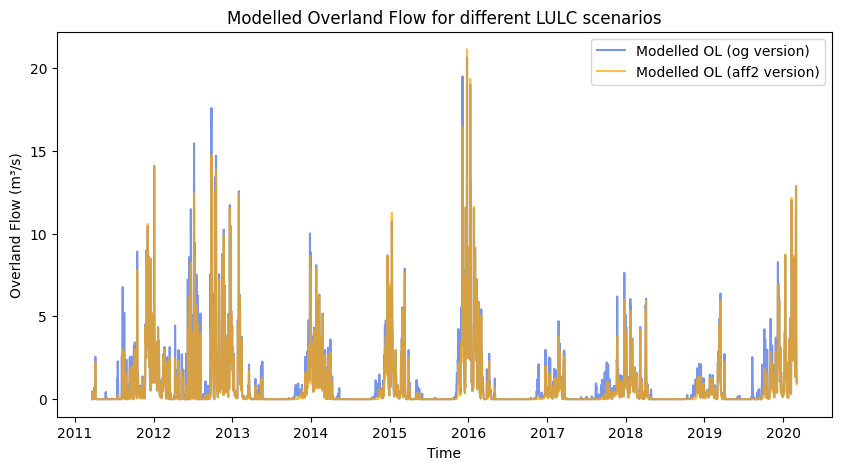

In [ ]:
# Middle Burn
# Plotting overland flow for each scenario

plt.figure(figsize=(10,5))

#plt.plot(MB_aff1_subset.index, MB_aff1_subset.OL, label="Modelled OL (aff1 version)", color = "red", alpha=0.7)
plt.plot(MB_scen1_subset.index, MB_scen1_subset.OL, label="Modelled OL (og version)", color = "royalblue", alpha=0.7)
plt.plot(MB_aff2_subset.index, MB_aff2_subset.OL, label="Modelled OL (aff2 version)", color = "orange", alpha=0.7)
#plt.plot(MB_wet_subset.index, MB_wet_subset.OL, label="Modelled OL (wet version)", color = "green", alpha=0.3)

plt.xlabel("Time")
plt.ylabel("Overland Flow (m³/s)")
plt.title("Modelled Overland Flow for different LULC scenarios")
plt.legend()

# plt.savefig("Timeseries_obsvsmod_og.png", dpi=300, bbox_inches='tight')
plt.show()

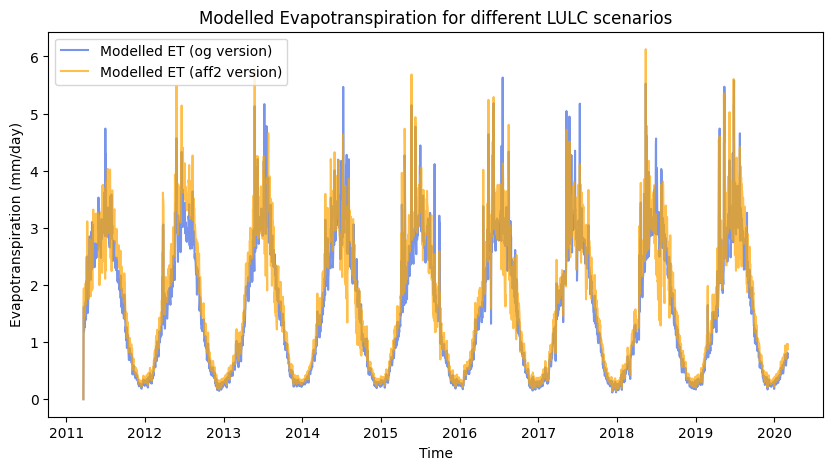

In [33]:
# Middle Burn - ET

# Middle Burn
# Plotting overland flow for each scenario

plt.figure(figsize=(10,5))

#plt.plot(MB_aff1_subset.index, MB_aff1_subset.ET, label="Modelled ET (aff1 version)", color = "red", alpha=0.7)
plt.plot(MB_scen1_subset.index, MB_scen1_subset.ET, label="Modelled ET (og version)", color = "royalblue", alpha=0.7)
plt.plot(MB_aff2_subset.index, MB_aff2_subset.ET, label="Modelled ET (aff2 version)", color = "orange", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Evapotranspiration (mm/day)")
plt.title("Modelled Evapotranspiration for different LULC scenarios")
plt.legend()

# plt.savefig("Timeseries_obsvsmod_og.png", dpi=300, bbox_inches='tight')
plt.show()

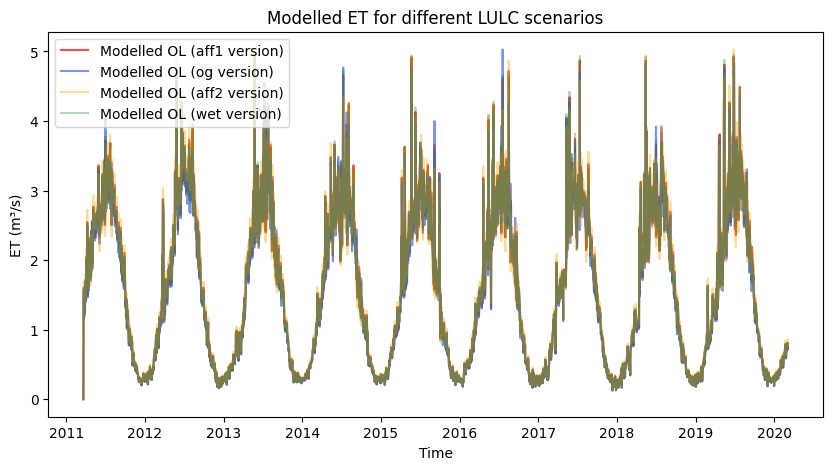

In [54]:
# Shiplaw Burn

plt.figure(figsize=(10,5))

plt.plot(SB_aff1_subset.index, SB_aff1_subset.ET, label="Modelled OL (aff1 version)", color = "red", alpha=0.7)
plt.plot(SB_scen1_subset.index, SB_scen1_subset.ET, label="Modelled OL (og version)", color = "royalblue", alpha=0.7)
plt.plot(SB_aff2_subset.index, SB_aff2_subset.ET, label="Modelled OL (aff2 version)", color = "orange", alpha=0.4)
plt.plot(SB_wet_subset.index, SB_wet_subset.ET, label="Modelled OL (wet version)", color = "green", alpha=0.3)

plt.xlabel("Time")
plt.ylabel("ET (m³/s)")
plt.title("Modelled ET for different LULC scenarios")
plt.legend()

# plt.savefig("Timeseries_obsvsmod_og.png", dpi=300, bbox_inches='tight')
plt.show()

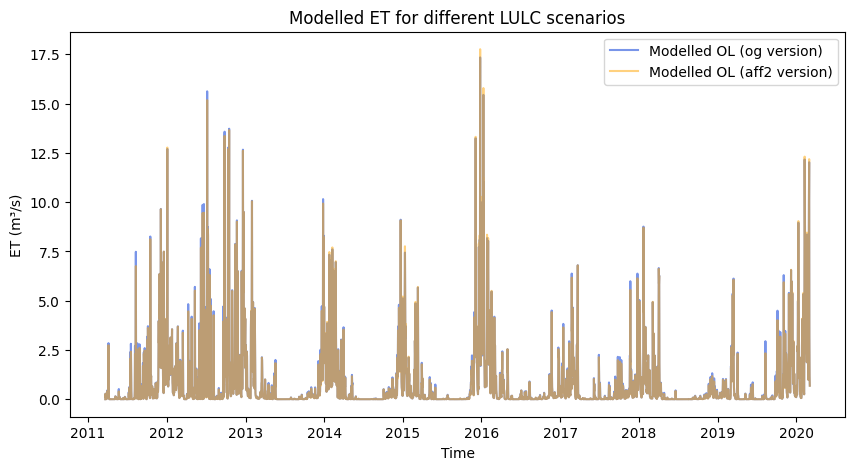

In [58]:
# Kidston Mill

plt.figure(figsize=(10,5))

#plt.plot(KM_aff1_subset.index, KM_aff1_subset.OL, label="Modelled OL (aff1 version)", color = "red", alpha=0.7)
plt.plot(KM_scen1_subset.index, KM_scen1_subset.OL, label="Modelled OL (og version)", color = "royalblue", alpha=0.7)
plt.plot(KM_aff2_subset.index, KM_aff2_subset.OL, label="Modelled OL (aff2 version)", color = "orange", alpha=0.5)
#plt.plot(KM_wet_subset.index, KM_wet_subset.OL, label="Modelled OL (wet version)", color = "green", alpha=0.3)

plt.xlabel("Time")
plt.ylabel("ET (m³/s)")
plt.title("Modelled ET for different LULC scenarios")
plt.legend()

# plt.savefig("Timeseries_obsvsmod_og.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Maybe look at accumulative ET and OL for each scenario, on a mean monthly basis ???

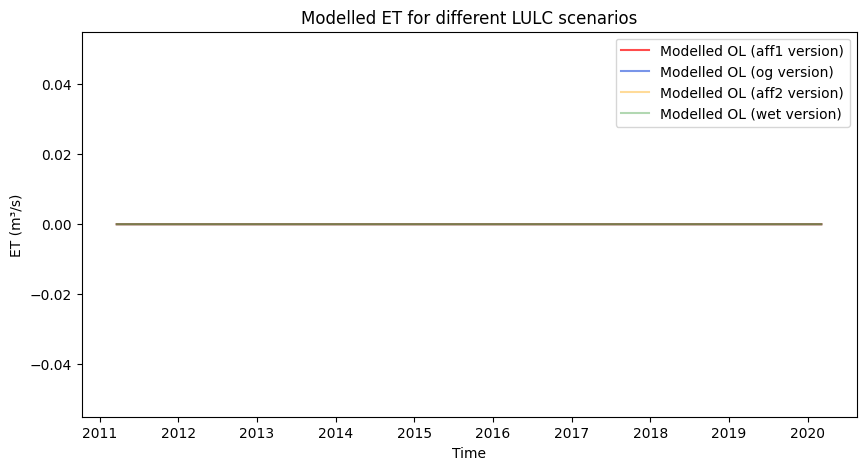

In [ ]:
# Middle Longcote

plt.figure(figsize=(10,5))

plt.plot(ML_aff1_subset.index, ML_aff1_subset.OL, label="Modelled OL (aff1 version)", color = "red", alpha=0.7)
plt.plot(ML_scen1_subset.index, ML_scen1_subset.OL, label="Modelled OL (og version)", color = "royalblue", alpha=0.7)
plt.plot(ML_aff2_subset.index, ML_aff2_subset.OL, label="Modelled OL (aff2 version)", color = "orange", alpha=0.4)
plt.plot(ML_wet_subset.index, ML_wet_subset.OL, label="Modelled OL (wet version)", color = "green", alpha=0.3)

plt.xlabel("Time")
plt.ylabel("ET (m³/s)")
plt.title("Modelled ET for different LULC scenarios")
plt.legend()

# plt.savefig("Timeseries_obsvsmod_og.png", dpi=300, bbox_inches='tight')
plt.show()



In [8]:
# Normalise timestamps to midnight
for df in [obs, og, scen2, scen3_a, scen3_p, scen4]:
    df.index = df.index.normalize()

# Trim obs
obs_trimmed = obs.loc[og.index.min():og.index.max()]

obs_clean = obs_trimmed.copy()
for col in obs_clean.columns:
    obs_clean[col] = obs_clean[col].where(obs_clean[col] > 0)

# Merge into a clean, normalized dataframe
merged = (
    obs_clean
    .join(og, how="inner", rsuffix="_og")
    .join(scen2, how="inner", rsuffix="_scen2")
    .join(scen3_a, how="inner", rsuffix="_scen3_a")
    .join(scen3_p, how="inner", rsuffix="_scen3_p")
    .join(scen4, how="inner", rsuffix="_scen4")
)

In [12]:
# Normalise timestamps to midnight
obs.index   = obs.index.normalize()
og.index = og.index.normalize()
scen2.index = scen2.index.normalize()
scen3_a.index = scen3_a.index.normalize()
scen3_p.index = scen3_p.index.normalize()
scen4.index = scen4.index.normalize()

# Trim observed data to match modelled outputs
obs_trimmed = obs.loc[
    og.index.min() : og.index.max()
]

# Keep only positive values
obs_trimmed_nozero = obs_trimmed[obs_trimmed > 0].dropna()

# 4. Merge all datasets using inner join
merged = (
    obs_trimmed_nozero
    .join(og, how="inner", rsuffix="_og")
    .join(scen2, how="inner", rsuffix="_scen2")
    .join(scen3_a, how="inner", rsuffix="_scen3_a")
    .join(scen3_p, how="inner", rsuffix="_scen3_p")
    .join(scen4, how="inner", rsuffix="_scen4")
)

In [17]:
obs_stats = pd.DataFrame({
    "Mean": obs_trimmed_nozero.mean(),
    "Q95": obs_trimmed_nozero.quantile(0.95),
    "Q5": obs_trimmed_nozero.quantile(0.05)
})

print(obs_stats)

                     Mean      Q95     Q5
Shiplaw_Burn     0.048577  0.21330  0.001
Middle_Burn      0.049932  0.18700  0.007
Middle_Longcote  0.059262  0.20200  0.011
Kidston_Mill     1.200883  4.13955  0.084


# Panel versions

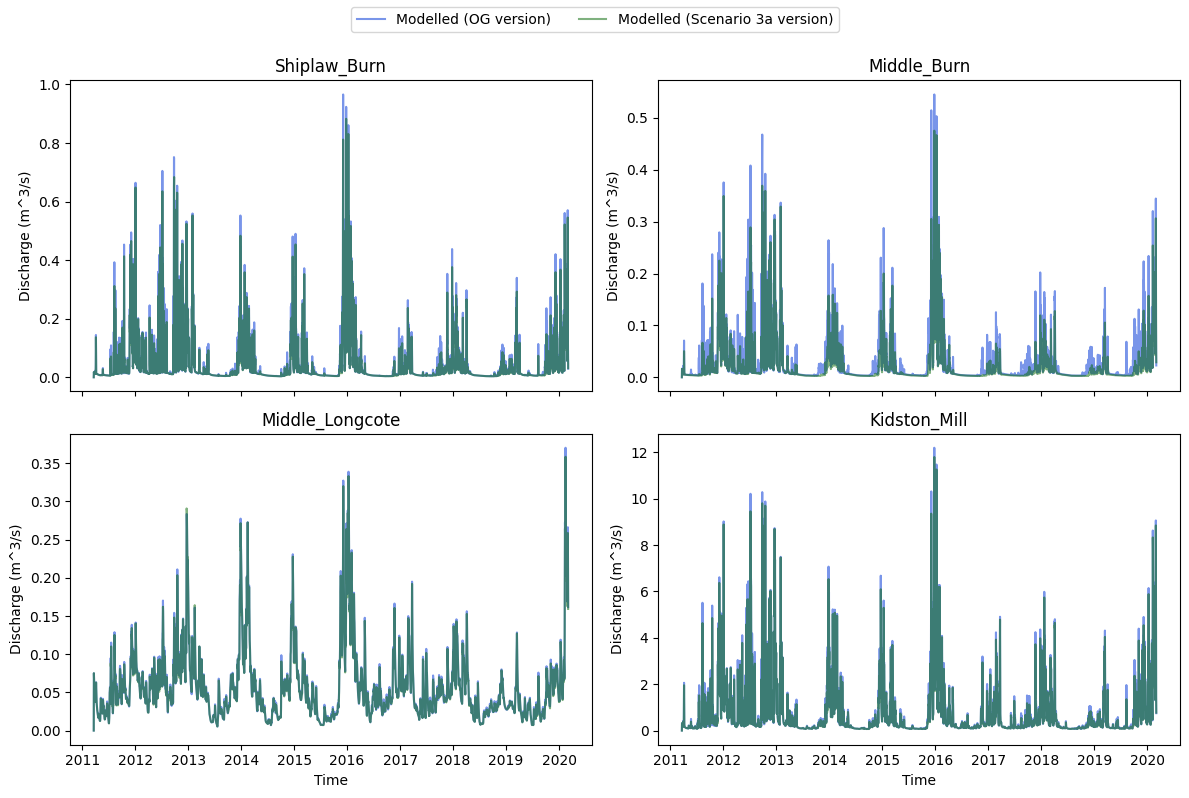

In [41]:
# og vs MB afforestation scenario

gauges = ["Shiplaw_Burn", "Middle_Burn", "Middle_Longcote", "Kidston_Mill"]

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharex=True)

axes = axes.flatten()

for i, gauge in enumerate(gauges):
    
    ax = axes[i]

    # Modelled lines

    ax.plot(og.index, og[gauge],
            label="Modelled (OG version)",
            color="royalblue", alpha=0.7)

    ax.plot(scen3_a.index, scen3_a[gauge],
            label="Modelled (Scenario 3a version)",
            color="darkgreen", alpha=0.5)


    ax.set_title(gauge)
    ax.set_ylabel("Discharge (m^3/s)")

# Common x-label
for ax in axes[2:]:
    ax.set_xlabel("Time")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0,0,1,0.95])

#plt.savefig("Timeseries_ogvsmod_vege2versions.png", dpi=300, bbox_inches="tight")
plt.show()

## Monthly regimes

In [42]:
# Computing monhtly regimes

obs_regime = obs_trimmed.groupby(obs_trimmed.index.month).mean()

og_regime = og.groupby(og.index.month).mean()
scen2_regime = scen2.groupby(scen2.index.month).mean()
scen3_a_regime = scen3_a.groupby(scen3_a.index.month).mean()
scen3_p_regime = scen3_p.groupby(scen3_p.index.month).mean()
scen4_regime = scen4.groupby(scen4.index.month).mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

obs_regime.index = month_names
og_regime.index = month_names
scen2_regime.index = month_names
scen3_a_regime.index = month_names
scen3_p_regime.index = month_names
scen4_regime.index = month_names

In [53]:
def create_regime(df_name):
    return pd.DataFrame({
        "OG model": og.groupby(og.index.month)[df_name].mean(),
        "Scen2": scen2.groupby(scen2.index.month)[df_name].mean(),
        "Scen3A": scen3_a.groupby(scen3_a.index.month)[df_name].mean(),
        "Scen3P": scen3_p.groupby(scen3_p.index.month)[df_name].mean(),
        #"Scen4": scen4.groupby(scen4.index.month)[df_name].mean(),
        #"Observed": obs_trimmed.groupby(obs_trimmed.index.month)[df_name].mean()
    })

In [54]:
regimes_SB = create_regime("Shiplaw_Burn")
regimes_MB = create_regime("Middle_Burn")
regimes_ML = create_regime("Middle_Longcote")
regimes_KM = create_regime("Kidston_Mill")

for df in [regimes_SB, regimes_MB, regimes_ML, regimes_KM]:
    df.index = month_names

In [55]:
# print monthly means
print(regimes_SB)

     OG model     Scen2    Scen3A    Scen3P
Jan  0.098210  0.098197  0.092484  0.098208
Feb  0.082771  0.082725  0.078732  0.082809
Mar  0.045740  0.045837  0.042628  0.045792
Apr  0.026200  0.026487  0.024277  0.026209
May  0.014893  0.014602  0.013106  0.014702
Jun  0.018351  0.018300  0.016670  0.018356
Jul  0.018386  0.018370  0.016859  0.018379
Aug  0.015152  0.015117  0.012355  0.015155
Sep  0.021776  0.021765  0.017966  0.021756
Oct  0.034220  0.034200  0.029712  0.034243
Nov  0.049440  0.049476  0.041749  0.049509
Dec  0.113125  0.113028  0.100812  0.113124


In [56]:
color_dict = {
    #"Observed": "grey",
    "OG model": "royalblue",
    "Scen2": "orange",
    "Scen3A": "darkgreen",
    "Scen3P": "brown",
    #"Scen4": "lightblue",
}

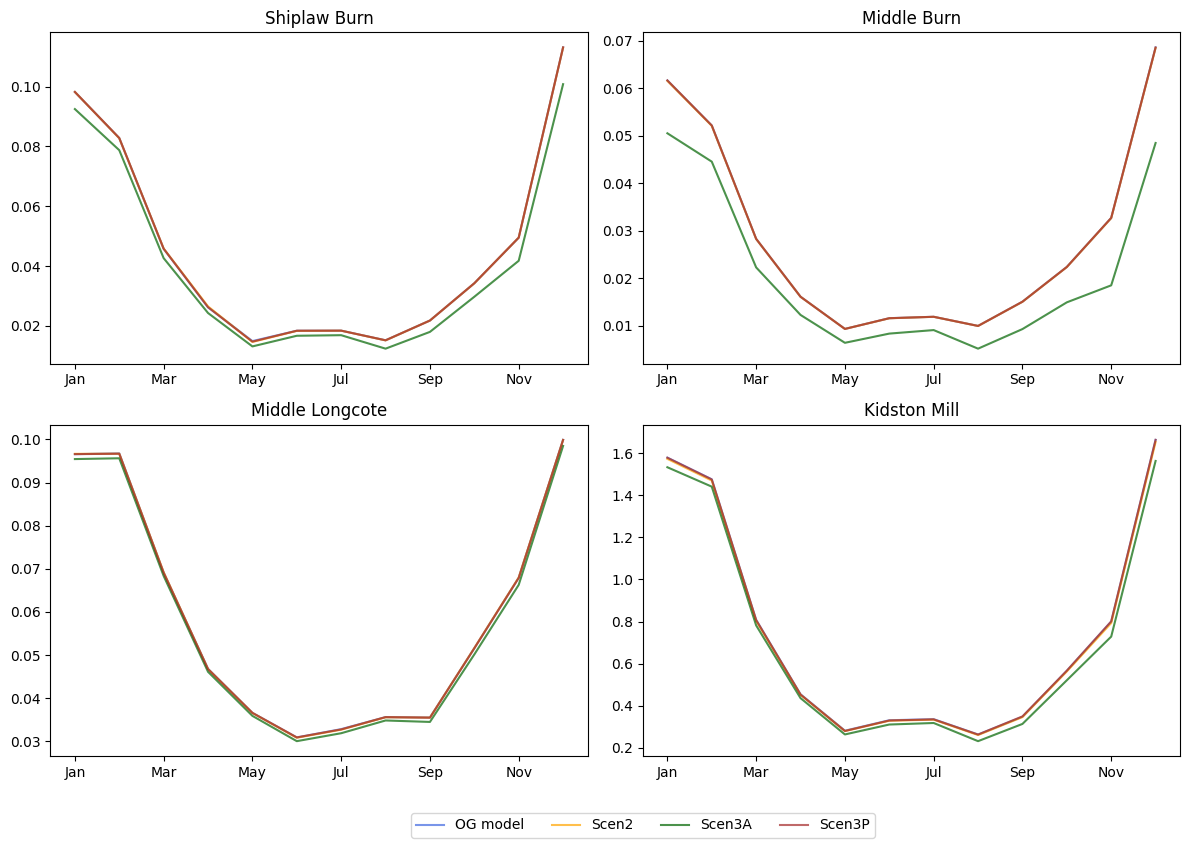

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

regimes_SB.plot(ax=axes[0,0], title="Shiplaw Burn", color=[color_dict[col] for col in regimes_SB.columns], alpha=0.7, legend = False)
regimes_MB.plot(ax=axes[0,1], title="Middle Burn", color=[color_dict[col] for col in regimes_SB.columns], alpha=0.7, legend=False)
regimes_ML.plot(ax=axes[1,0], title="Middle Longcote", color=[color_dict[col] for col in regimes_SB.columns], alpha=0.7, legend=False)
regimes_KM.plot(ax=axes[1,1], title="Kidston Mill", color=[color_dict[col] for col in regimes_SB.columns], alpha=0.7, legend=False)

for ax in axes.flatten():
    ax.grid(False)

plt.tight_layout()
plt.legend(loc="upper center", bbox_to_anchor=(0, -0.15), ncol=4)

plt.savefig("MonthlyRegimesLC_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()


In [62]:
# Convert daily to monthly mean

obs_monthly = obs.resample("ME").mean()
og_monthly = og.resample("ME").mean()
scen2_monthly = scen2.resample("ME").mean()
scen3a_monthly = scen3_a.resample("ME").mean()
scen3p_monthly = scen3_p.resample("ME").mean()
scen4_monthly = scen4.resample("ME").mean()

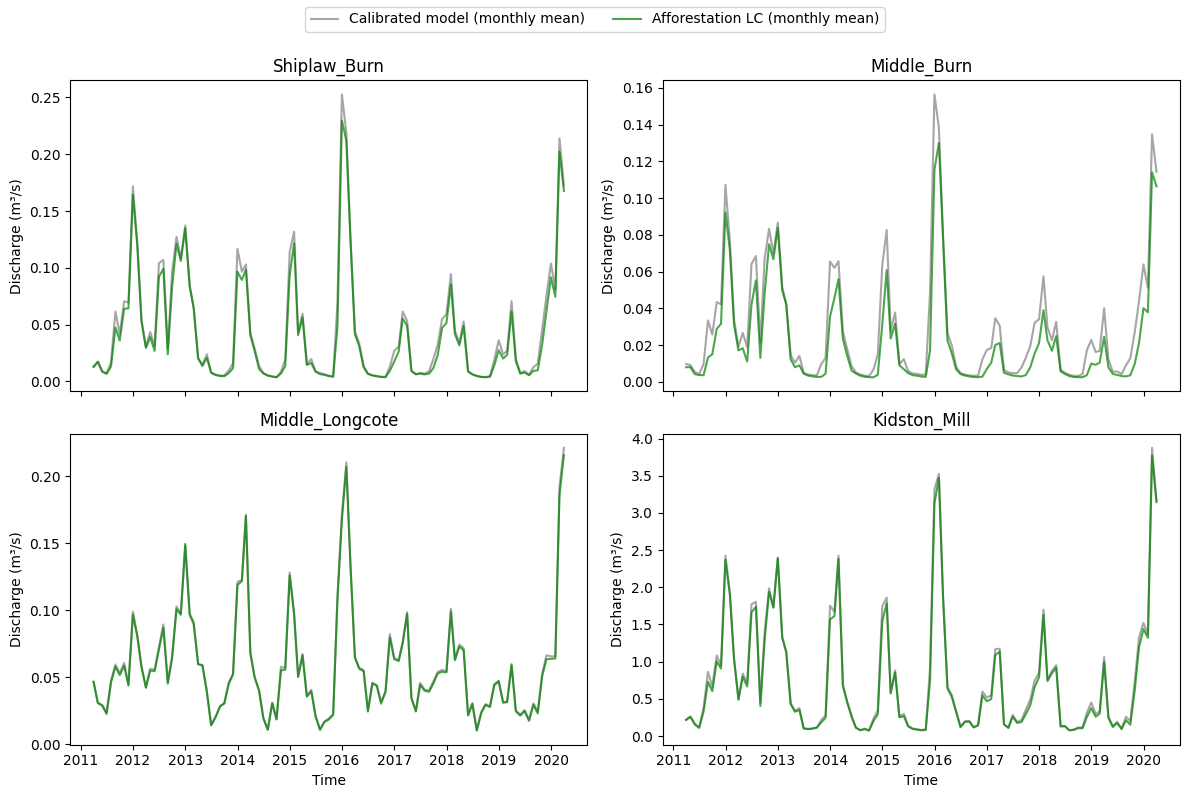

In [63]:
# Monthly plots

gauges = ["Shiplaw_Burn", "Middle_Burn", "Middle_Longcote", "Kidston_Mill"]

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharex=True)
axes = axes.flatten()

split_date = pd.to_datetime("2016-03-05")

for i, gauge in enumerate(gauges):
    
    ax = axes[i]

    # Modelled monthly mean
    ax.plot(og_monthly.index, og_monthly[gauge],
            label="Calibrated model (monthly mean)", color="grey", alpha=0.7)
    
    ax.plot(scen3a_monthly.index, scen3a_monthly[gauge],
            label="Afforestation LC (monthly mean)", color="green", alpha=0.7)

    ax.set_title(gauge)
    ax.set_ylabel("Discharge (m³/s)")

# Common x-label
for ax in axes[2:]:
    ax.set_xlabel("Time")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("Timeseries_MBafforestation.png", dpi=300, bbox_inches="tight")
plt.show()
